In [ ]:
# source venv/bin/activate  

import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from dataclasses import asdict
import warnings
from pandas.errors import SettingWithCopyWarning
from functools import partial
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings("ignore", message=".*not in pamset.*")

from meteor import MeteorPatternScaling, meteor_plot_utils
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
from meteor import scm_forcer_engine
from ciceroscm import CICEROSCM
from ciceroscm import input_handler

from meteor.prpatt import global_mean
from meteor.prpatt import recon

#import cartopy.crs as ccrs
#import cartopy as cart
from matplotlib.gridspec import GridSpec
from scipy.interpolate import griddata

In [2]:
## NBVAL_IGNORE_OUTPUT
#sys.path.insert(0,os.path.join(os.getcwd(), '../'))
#module_path = os.path.abspath(os.path.join('../src'))
#if module_path not in sys.path:
#    sys.path.append(module_path)

#cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

In [2]:
savecache=1
#loadcache=1

cachedir = os.path.join(os.getcwd(), "cache")
if not os.path.exists(cachedir):
        os.makedirs(cachedir)
        
figdir = os.path.join(os.getcwd(), "figures")
if not os.path.exists(figdir):
        os.makedirs(figdir)

cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

# Data preparations

Getting CMIP6 data from the zarrstore for tas

In [3]:
scenarios = [ "ssp126", "ssp245", "ssp370", "ssp585"]
flds = ["tas","pr"]
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical", "ssp126", "ssp245", "ssp370", "ssp585"], 
                                    flds = flds, 
                                    dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP', 'ScenarioMIP','ScenarioMIP', 'ScenarioMIP'])

#for property, value in vars(data_getter).items():
#    print(property)

In [4]:
models = data_getter.models
len(models)

35

Create training data dictionary for all selected models (may run for a while) - and save locally in 'cache' (cachedir) due to data memory requirements

In [5]:
# remove problematic models
if 'EC-Earth3-Veg' in models: models.pop(models.index('EC-Earth3-Veg'))  # too big
#if 'MCM-UA-1-0' in models: models.pop(models.index('MCM-UA-1-0'))  # drop because of some data issue
#if 'MIROC-ES2L' in models: models.pop(models.index('MIROC-ES2L'))  # drop because of some data issue
#if 'MIROC6' in models: models.pop(models.index('MIROC6'))  # drop because of some data issue
#if 'MPI-ESM1-2-HR' in models: models.pop(models.index('MPI-ESM1-2-HR'))  # drop because of some data issue
#if 'MPI-ESM1-2-LR' in models: models.pop(models.index('MPI-ESM1-2-LR'))  # drop because of some data issue

#if 'IPSL-CM6A-LR' in models: models.pop(models.index('IPSL-CM6A-LR'))    # drop IPSL-CM6A-LR because of NaN values in tas
#if 'NESM3' in models: models.pop(models.index('NESM3'))    # drop IPSL-CM6A-LR because of NaN values in tas
#if 'IITM-ESM' in models: models.pop(models.index('IITM-ESM'))            # drop IITM-ESM because pattern exctraction fails for tas
#if 'MRI-ESM2-0' in models: models.pop(models.index('MRI-ESM2-0'))        # drop MRI-ESM2-0 because of NaN values in pr
#if 'EC-Earth3' in models: models.pop(models.index('EC-Earth3'))          # drop EC-Earth3 because of NaN values in pr

In [6]:
models = models[15:]
models

['FGOALS-f3-L',
 'FGOALS-g3',
 'GFDL-ESM4',
 'GISS-E2-1-G',
 'GISS-E2-1-H',
 'IITM-ESM',
 'INM-CM4-8',
 'INM-CM5-0',
 'IPSL-CM6A-LR',
 'KACE-1-0-G',
 'MCM-UA-1-0',
 'MIROC-ES2L',
 'MIROC6',
 'MPI-ESM1-2-HR',
 'MPI-ESM1-2-LR',
 'MRI-ESM2-0',
 'NorESM2-MM',
 'TaiESM1',
 'UKESM1-0-LL']

In [7]:
if savecache:
    #training_data_dict = {}
    for nm,mname in enumerate(models):
        print(nm, mname)

        # create model-specific training data
        #training_data_dict[mname] = {
        training_data = {
            "base": data_getter.make_meteor_training_data("base", mname),
            "co2x4": data_getter.make_meteor_training_data("co2x4", mname),
            "sulxanom": data_getter.make_meteor_training_data_composite(["historical", "ssp245"], mname),
        }

        for s in scenarios:
                training_data[s]=data_getter.make_meteor_training_data_composite(
                        ["historical", s], mname
                    )

        # save data locally (cache) to avoid running this cell again and again when accessing data
        for k in training_data:
            training_data[k].to_netcdf(os.path.join(cachedir, f"{mname}_{k}_training_data.nc"))

0 FGOALS-f3-L


KeyboardInterrupt: 

Load locally saved training data

In [7]:
#if loadcache:
training_data_dict={}
for nm,mname in enumerate(models):
    #print(nm,mname)

    training_data_dict[mname] = {
        "base": xr.open_dataset(os.path.join(cachedir, f"{mname}_base_training_data.nc")),
        "co2x4": xr.open_dataset(os.path.join(cachedir, f"{mname}_co2x4_training_data.nc")),
        "sulxanom": xr.open_dataset(os.path.join(cachedir, f"{mname}_sulxanom_training_data.nc")),
    }

Getting some data that can be used by the forcer engine and ciceroscm

In [8]:
%%capture
# NBVAL_IGNORE_OUTPUT

#For predictions: 
conc_data = input_handler.read_inputfile(
    os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt")
)
ih = input_handler.InputHandler({})
em_data = ih.read_emissions(os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt"))

# GHG patterns

Create GHG modes and patterns for all selected models

In [11]:
%%capture

CMIP_ghg_pattern_dict = {}
for nm,mname in enumerate(models):

    # select model-specific training data
    training_data = training_data_dict[mname]

    # create GHG modes and spatial pattern
    CMIP_ghg_pattern_dict[mname] = MeteorPatternScaling(
            mname,
            {"tas": 2, "pr": 2},
            lambda key: training_data[key],
            from_file=False,
            exp_list=["base", "co2x4"],
        )


Plot single model responses (tas + pr)

In [12]:
%%capture

vmins = [-3,-15]
vmaxs = [3,15]
cmaps = ["RdBu_r","BrBG"]

# prepare figure canvas
fig = plt.figure(figsize=(15,len(models)*2.5))
gs = GridSpec(len(models), 3, figure=fig)

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):

        # create figure row by row
        sub = fig.add_subplot(gs[nm, 0])
        sub.set_xlabel("Years")
        sub.set_ylabel("$\Delta$"+var)
        sub.plot(global_mean(CMIP_ghg_pattern_dict[mname].dacanom[var][CMIP_ghg_pattern_dict[mname].exp_list.index('co2x4'), :100, :, :]), color="gray", label="Original data")
        sub.plot(global_mean(recon(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full'])), color="tab:blue", label="Fit to PCs (t=2)")
        sub.legend(frameon=False)
        sub.annotate(mname, xy=(0.02, 0.92), xycoords='axes fraction', fontsize=10, ha='left', va='center', weight="bold")

        sub = fig.add_subplot(gs[nm, 1])  #,projection=ccrs.PlateCarree())   #sub.coastlines()
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lat, 
                            CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])   # ,transform=cart.crs.PlateCarree()

        sub = fig.add_subplot(gs[nm, 2])
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lat,
                            CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][1, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])
        
    #plt.savefig(os.path.join(figdir, "CMIP_GHG_pattern_"+var+".jpg"), bbox_inches='tight')
    plt.savefig(os.path.join(figdir, "CMIP_GHG_pattern_"+var+".jpg"), bbox_inches='tight')

Multi-model composite

In [13]:
### global mean timeseries
CMIP_GHG_gm_response_co2x4 = np.zeros([len(flds),len(models),100]) * np.nan
CMIP_GHG_gm_response_recon_co2x4 = np.zeros([len(flds),len(models),100]) * np.nan
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        CMIP_GHG_gm_response_co2x4[nv,nm,:] = global_mean(CMIP_ghg_pattern_dict[mname].dacanom[var][CMIP_ghg_pattern_dict[mname].exp_list.index('co2x4'), :100, :, :])
        CMIP_GHG_gm_response_recon_co2x4[nv,nm,:] = global_mean(recon(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full']))

In [14]:
# interpolate gridded data to common grid

target_model_grid = 'NorESM2-LM'

# Define (new) common grid
common_lons = CMIP_ghg_pattern_dict[target_model_grid].pattern_dict['co2x4']['tas']["pattern_full"]["v"][0, :, :].lon  # Adjust the number of points as needed
common_lats = CMIP_ghg_pattern_dict[target_model_grid].pattern_dict['co2x4']['tas']["pattern_full"]["v"][0, :, :].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

# Interpolate to native grid and data
common_grid_ghg_data_T1 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
common_grid_ghg_data_T2 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        native_data_T1 = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :]
        native_data_T2 = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][1, :, :]
        native_lons = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lon
        native_lats = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lat
        native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)

        # Interpolate
        common_grid_ghg_data_T1[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data_T1).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')
        common_grid_ghg_data_T2[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data_T2).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')

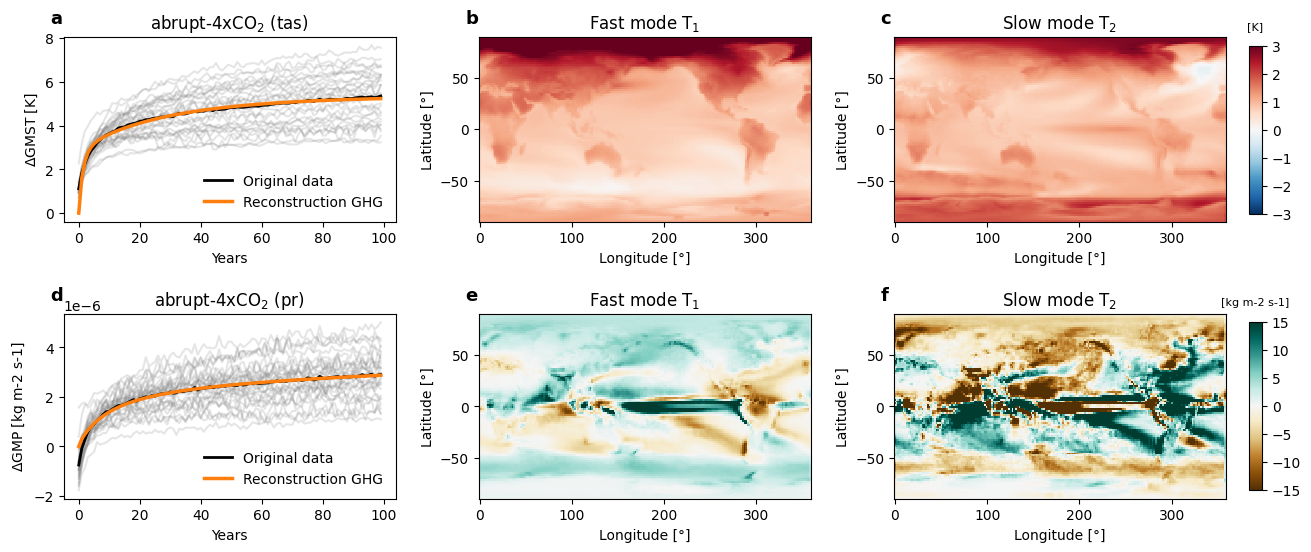

In [15]:
vmins = [-3,-15]
vmaxs = [3,15]
units = ["[K]","[kg m-2 s-1]"]
titles = ["$\Delta$GMST [K]", "$\Delta$GMP [kg m-2 s-1]"]
labels = (["a","b","c"],
          ["d","e","f"])
cmaps = ["RdBu_r","BrBG"]

fig = plt.figure(figsize=(15,6))
gs = GridSpec(2, 3, figure=fig)

for nv,var in enumerate(flds):

    sub = fig.add_subplot(gs[nv, 0])
    sub.set_title("abrupt-4xCO$_2$ ("+var+")")
    sub.set_xlabel("Years")
    sub.set_ylabel(titles[nv])
    #sub.set_xlim(0,100)
    #sub.set_ylim(0,8)
    for nm,mname in enumerate(models):
        sub.plot(global_mean(CMIP_ghg_pattern_dict[mname].dacanom[var][CMIP_ghg_pattern_dict[mname].exp_list.index('co2x4'), :100, :, :]), color="gray", alpha=0.2)
        #sub.plot(global_mean(recon(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full'])), color="gray", alpha=0.3)
    sub.plot(np.nanmean(CMIP_GHG_gm_response_co2x4[nv,:,:],0), color="black", lw=2, label="Original data")
    sub.plot(np.nanmean(CMIP_GHG_gm_response_recon_co2x4[nv,:,:],0), color="tab:orange", lw=2.5, label="Reconstruction GHG")
    sub.legend(frameon=False)
    sub.annotate(labels[nv][0], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nv, 1])#, projection=ccrs.PlateCarree()) 
    #sub.coastlines(lw=0.5)
    sub.set_title("Fast mode T$_1$")
    sub.set_xlabel("Longitude [°]")
    sub.set_ylabel("Latitude [°]")
    cont = sub.pcolormesh(common_lons, common_lats, np.nanmean(common_grid_ghg_data_T1[nv,:,:,:],0), cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])#, transform=cart.crs.PlateCarree())
    sub.annotate(labels[nv][1], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nv, 2])#, projection=ccrs.PlateCarree())
    #sub.coastlines(lw=0.5)
    sub.set_title("Slow mode T$_2$")
    sub.set_xlabel("Longitude [°]")
    sub.set_ylabel("Latitude [°]")
    cont = sub.pcolormesh(common_lons, common_lats, np.nanmean(common_grid_ghg_data_T2[nv,:,:,:],0), cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])#, transform=cart.crs.PlateCarree())
    sub.annotate(labels[nv][2], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    # external colorbar
    if var == "tas":
        cbar = fig.add_axes([0.915, 0.585, 0.009, 0.28])
    if var == "pr":
        cbar = fig.add_axes([0.915, 0.125, 0.009, 0.28])
    fig.colorbar(cont, cax=cbar,orientation='vertical')
    cbar.set_title(units[nv], size=8, pad=12, ha="center")

fig.subplots_adjust(wspace=0.25, hspace=0.5)
plt.savefig(os.path.join(figdir, "CMIP_GHG_pattern_composite.pdf"), bbox_inches='tight')

# Aerosol patterns

Taking ssp-data for ciceroscm and making predictions <br> 
(for GHGonly using CMIP_ghg_pattern_dict, which will be deleted after this (as not needed herafter) to prevent memory issues)

In [16]:
%%capture

patterns_ghg={}
for nm,mname in enumerate(models):
    patterns_ghg[mname] = CMIP_ghg_pattern_dict[mname].predict_from_combined_experiment(
            em_data, conc_data, ["pr", "tas"]
    )

In [17]:
# delete here (as not used herafter), to make 'space' for aerosol pattern dictionary
del(CMIP_ghg_pattern_dict)

In [18]:
%%capture

CMIP_aer_pattern_dict = {}
for nm,mname in enumerate(models):

    # select model-specific training data
    training_data = training_data_dict[mname]

    # create GHG modes and spatial pattern
    CMIP_aer_pattern_dict[mname] = MeteorPatternScaling(
            mname,
            {"tas": 2, "pr": 2},
            lambda key: training_data[key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
        )

Taking ssp-data for ciceroscm and making predictions

In [19]:
%%capture

patterns_anomsulf={}

for nm,mname in enumerate(models):
    patterns_anomsulf[mname] = CMIP_aer_pattern_dict[mname].predict_from_combined_experiment(
            em_data, conc_data, ["pr", "tas"]
    )

In [20]:
### global mean timeseries
CMIP_aer_gm_response_sulxanom = np.zeros([len(flds),len(models),251]) * np.nan
CMIP_aer_gm_response_recon_ghgonly = np.zeros([len(flds),len(models),251]) * np.nan
CMIP_aer_gm_response_recon_sulxanom = np.zeros([len(flds),len(models),251]) * np.nan
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        CMIP_aer_gm_response_sulxanom[nv,nm,:] = global_mean(CMIP_aer_pattern_dict[mname].dacanom[var][CMIP_aer_pattern_dict[mname].exp_list.index('sulxanom'), :251, :, :])
        CMIP_aer_gm_response_recon_ghgonly[nv,nm,:] = global_mean(patterns_ghg[mname][var]).values[100:]
        CMIP_aer_gm_response_recon_sulxanom[nv,nm,:] = global_mean(patterns_anomsulf[mname][var]).values[100:]


In [21]:
# interpolate gridded data to common grid

target_model_grid = 'NorESM2-LM'

# Define (new) common grid
common_lons = CMIP_aer_pattern_dict[target_model_grid].pattern_dict['sulxanom']['tas']["pattern_full"]["v"][0, :, :].lon  # Adjust the number of points as needed
common_lats = CMIP_aer_pattern_dict[target_model_grid].pattern_dict['sulxanom']['tas']["pattern_full"]["v"][0, :, :].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

# Interpolate to native grid and data
common_grid_aer_data_T1 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
common_grid_aer_data_T2 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        native_data_T1 = CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :]
        native_data_T2 = CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][1, :, :]
        native_lons = CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lon
        native_lats = CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lat
        native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)

        # Interpolate
        common_grid_aer_data_T1[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data_T1).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')
        common_grid_aer_data_T2[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data_T2).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')

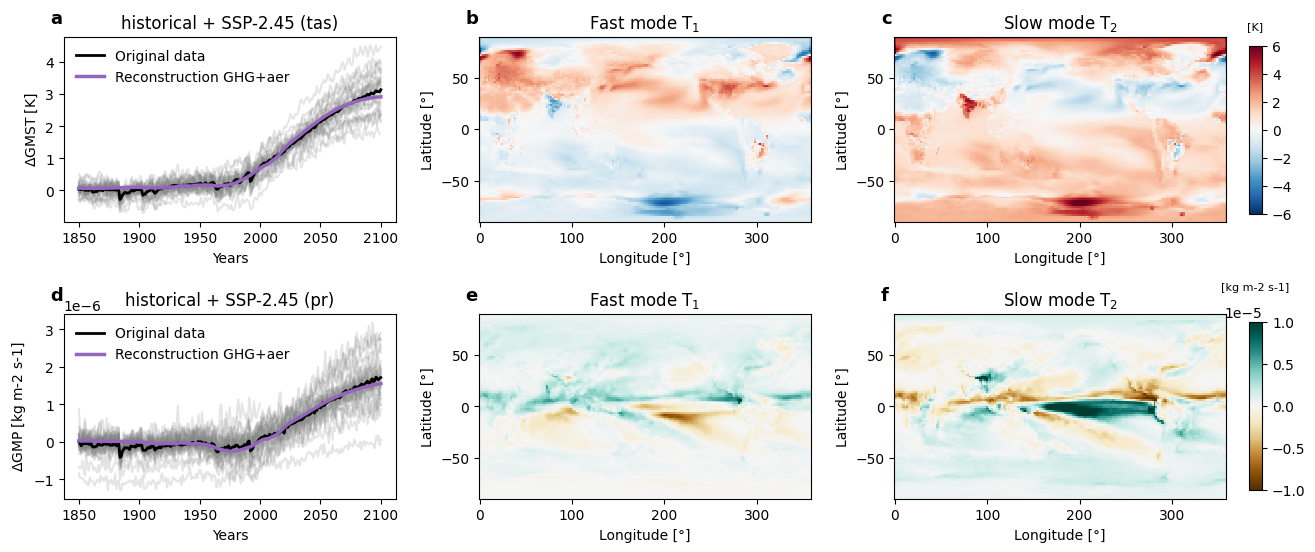

In [22]:
vmins = [-6,-1e-5]
vmaxs = [6,1e-5]
units = ["[K]","[kg m-2 s-1]"]
titles = ["$\Delta$GMST [K]", "$\Delta$GMP [kg m-2 s-1]"]
labels = (["a","b","c"],
          ["d","e","f"])
cmaps = ["RdBu_r","BrBG"]

fig = plt.figure(figsize=(15,6))
gs = GridSpec(2, 3, figure=fig)

for nv,var in enumerate(flds):

    sub = fig.add_subplot(gs[nv, 0])
    sub.set_title("historical + SSP-2.45 ("+var+")")
    sub.set_xlabel("Years")
    sub.set_ylabel(titles[nv])
    #sub.set_xlim(0,100)
    #sub.set_ylim(0,8)
    for nm,mname in enumerate(models):
        sub.plot(np.arange(1850,2101),global_mean(CMIP_aer_pattern_dict[mname].dacanom[var][CMIP_aer_pattern_dict[mname].exp_list.index('sulxanom'), :251, :, :]), color="gray", alpha=0.2)
    sub.plot(np.arange(1850,2101),np.nanmean(CMIP_aer_gm_response_sulxanom[nv,:,:],0), color="black", lw=2, label="Original data")
    #sub.plot(np.arange(1850,2101), np.nanmean(CMIP_aer_gm_response_recon_ghgonly[nv,:,:],0), color="tab:orange", lw=2.5, label="Reconstruction GHGonly",linestyle='--')
    sub.plot(np.arange(1850,2101), np.nanmean(CMIP_aer_gm_response_recon_sulxanom[nv,:,:],0), color="tab:purple", lw=2.5, label="Reconstruction GHG+aer")
    sub.legend(frameon=False)
    sub.annotate(labels[nv][0], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nv, 1])#, projection=ccrs.PlateCarree()) 
    #sub.coastlines(lw=0.5)
    sub.set_title("Fast mode T$_1$")
    sub.set_xlabel("Longitude [°]")
    sub.set_ylabel("Latitude [°]")
    cont = sub.pcolormesh(common_lons, common_lats, np.nanmean(common_grid_aer_data_T1[nv,:,:,:],0), cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])#, transform=cart.crs.PlateCarree())
    sub.annotate(labels[nv][1], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nv, 2])#, projection=ccrs.PlateCarree())
    #sub.coastlines(lw=0.5)
    sub.set_title("Slow mode T$_2$")
    sub.set_xlabel("Longitude [°]")
    sub.set_ylabel("Latitude [°]")
    cont = sub.pcolormesh(common_lons, common_lats, np.nanmean(common_grid_aer_data_T2[nv,:,:,:],0), cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])#, transform=cart.crs.PlateCarree())
    sub.annotate(labels[nv][2], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    # external colorbar
    if var == "tas":
        cbar = fig.add_axes([0.915, 0.585, 0.009, 0.28])
    if var == "pr":
        cbar = fig.add_axes([0.915, 0.125, 0.009, 0.28])
    fig.colorbar(cont, cax=cbar,orientation='vertical')
    cbar.set_title(units[nv], size=8, pad=12, ha="center")

fig.subplots_adjust(wspace=0.25, hspace=0.5)
plt.savefig(os.path.join(figdir, "CMIP_aer_pattern_composite.pdf"), bbox_inches='tight')

In [25]:
# delete here to make 'space' for aerosol pattern dictionary
del(CMIP_aer_pattern_dict)

# Evaluation of timescale separation

In [137]:
%%capture

timescales=[1,2,3,4,5]
mae = np.zeros([len(flds),len(models),len(timescales)])
rmse = np.zeros([len(flds),len(models),len(timescales)])
CMIP_ghg_pattern_dict_tscales = {}

for nm,mname in enumerate(models):

    # select model-specific training data
    training_data = training_data_dict[mname]

    # create GHG modes and spatial pattern
    for nts,ts in enumerate(timescales):

        CMIP_ghg_pattern_dict_tscales = MeteorPatternScaling(
                mname,
                {"tas": ts, "pr": ts},
                lambda key: training_data[key],
                from_file=False,
                exp_list=["base", "co2x4"],
            )

        # calculate goodness of the fit vs. orginal data
        for nv,var in enumerate(flds):
            ts1 = global_mean(CMIP_ghg_pattern_dict_tscales.dacanom[var][CMIP_ghg_pattern_dict_tscales.exp_list.index('co2x4'), :100, :, :])
            ts2 = global_mean(recon(CMIP_ghg_pattern_dict_tscales.pattern_dict['co2x4'][var]['pattern_full']))
            mae[nv,nm,nts] = np.abs(ts1-ts2).mean()
            rmse[nv,nm,nts] = np.sqrt(np.mean((ts1-ts2)**2))



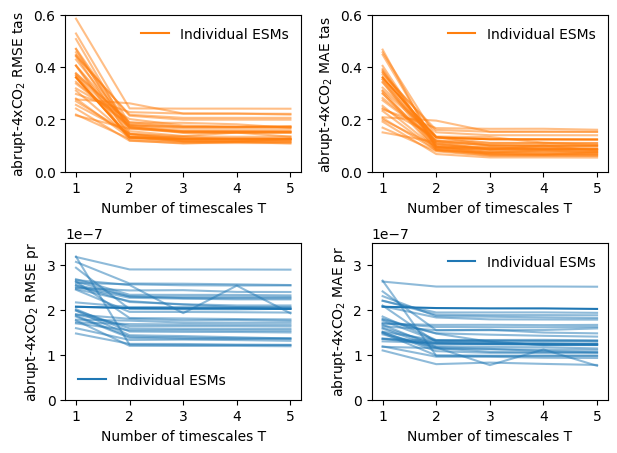

In [168]:
ylims_min=[0,0e-7]
ylims_max=[0.6,3.5e-7]
colors=["tab:orange","tab:blue"]

fig = plt.figure(figsize=(7,5))
gs = GridSpec(2, 2, figure=fig)

for nv,var in enumerate(flds):

    sub = fig.add_subplot(gs[nv, 0])
    sub.set_ylabel('abrupt-4xCO$_2$ RMSE '+var)
    sub.set_xlabel('Number of timescales T')
    sub.set_ylim(ylims_min[nv],ylims_max[nv])
    sub.set_xticks([0,1,2,3,4])
    sub.set_xticklabels([1,2,3,4,5])
    for m in np.arange(0,rmse.shape[1]):
        if m == 1: sub.plot(rmse[nv,m,:], color=colors[nv], label="Individual ESMs")
        sub.plot(rmse[nv,m,:], color=colors[nv],alpha=0.5)
    sub.legend(frameon=False)

    sub = fig.add_subplot(gs[nv, 1])
    sub.set_xlabel('Number of timescales T')
    sub.set_ylabel('abrupt-4xCO$_2$ MAE '+var)
    sub.set_ylim(ylims_min[nv],ylims_max[nv])
    sub.set_xticks([0,1,2,3,4])
    sub.set_xticklabels([1,2,3,4,5])
    for m in np.arange(0,mae.shape[1]):
        if m == 1: sub.plot(rmse[nv,m,:], color=colors[nv], label="Individual ESMs")
        sub.plot(mae[nv,m,:], color=colors[nv],alpha=0.5)
    sub.legend(frameon=False)

fig.subplots_adjust(wspace=0.3, hspace=0.45)
plt.savefig(os.path.join(figdir, "fit_timescale_evaluation.pdf"), bbox_inches='tight')

# Application to new scenarios

Standard SSPs

In [167]:
len(models)

38

In [155]:
%%capture
ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

#For predictions: 
#read in SSP245 concentrations and emissions

scenarios = ["ssp126","ssp245","ssp585"]

conc_data=[]
em_data=[]
for i,s in enumerate(scenarios):
    conc_data.append(input_handler.read_inputfile(
    os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")
    ))

    em_data.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

ssp534-over